# Real use oF NN- MNIST dataset

### Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

### Load MNIST dataset

In [2]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)


### Data loaders

In [3]:
batch_size = 64

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False
)
epochs = 5


Instead of each forward pass computing gradients on the full 60k training set, we split the training data into mini-batches of 64 images, compute gradients for each batch, and iterate over all batches once per epoch — repeating this process 5 times (5 epochs).

### Visualize 10 digits

Each digit is just a 28×28 array of numbers

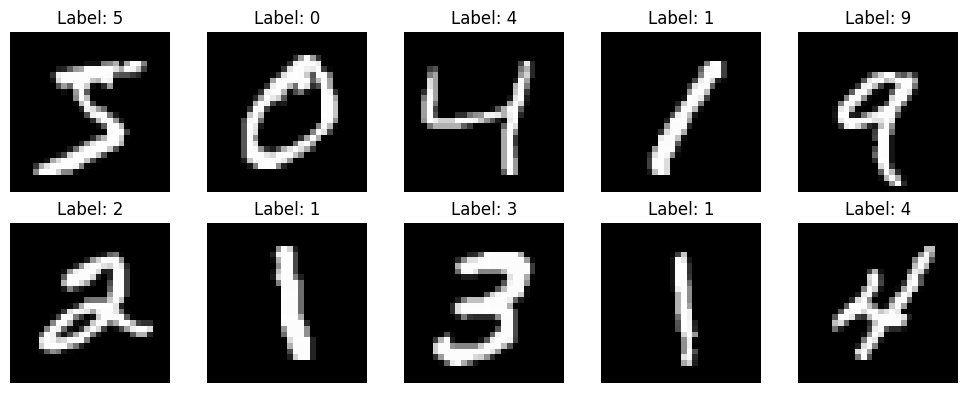

In [4]:
plt.figure(figsize=(10, 4))

for i in range(10):
    image, label = train_dataset[i]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()


### Neural Network for MNIST

In [5]:
class MNIST_NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)           # logits
        return x


### Initialize model, loss, optimizer

In [6]:
model = MNIST_NN()

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)


### Training loop

In [7]:
losses = []

for epoch in range(epochs):
    total_loss = 0.0

    for images, labels in train_loader:
        # Forward
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")


Epoch [1/5], Loss: 0.4381
Epoch [2/5], Loss: 0.2241
Epoch [3/5], Loss: 0.1690
Epoch [4/5], Loss: 0.1362
Epoch [5/5], Loss: 0.1139


### Plot training loss

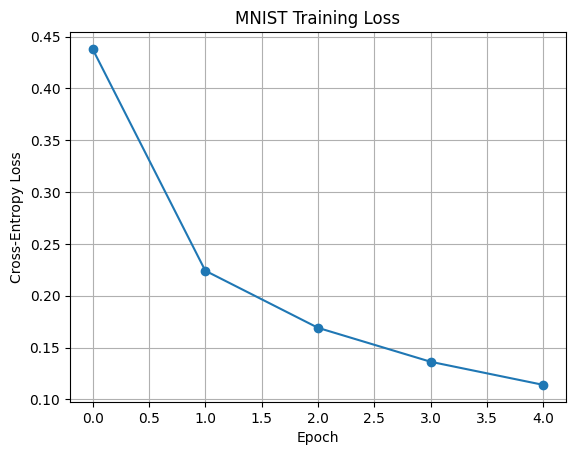

In [8]:
plt.plot(losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("MNIST Training Loss")
plt.grid(True)
plt.show()


### Evaluate on test set (accuracy)

In [9]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy}")


Accuracy: 96.71


# How to add stuff to your net

## Xavier (Glorot) weight initialization

In [ ]:
def init_weights_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
model = Net()
model.apply(init_weights_xavier)


## Batch Normalization

In [10]:
class MNIST_NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.bn1 = nn.BatchNorm1d(128)   # <-- BatchNorm added
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.bn1(x)                 # <-- BatchNorm here
        x = torch.relu(x)
        x = self.fc2(x)
        return x


## Dropout

In [11]:
class MNIST_NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(p=0.5)   # <-- Dropout added


    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.dropout(x)                 # <-- Dropout here
        x = self.fc2(x)
        return x


## Gradient Clipping

In [ ]:
loss.backward()

torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=1.0
)

optimizer.step()


## Learning-Rate Scheduling

In [ ]:
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)


## Different optimizers

### SGD

In [12]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.0
)


### SGD + Momentum

In [13]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9
)


### Adam

In [14]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


### RMSProp

In [15]:
optimizer = torch.optim.RMSprop(
    model.parameters(),
    lr=1e-3
)


# All together:

### Define a NN class

In [16]:
class NN(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(28 * 28, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(128, 10)

        # Apply Glorot (Xavier) initialization
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = x.view(x.size(0), -1)     # flatten

        x = self.fc1(x)
        x = self.bn1(x)               # BatchNorm BEFORE activation
        x = F.relu(x)
        x = self.dropout(x)           # Dropout AFTER activation

        x = self.fc2(x)               # logits
        return x


### Define a new model, optimizer and loss function

In [17]:
model = NN()

optimizer = torch.optim.RMSprop(
    model.parameters(),
    lr=1e-3,
    alpha=0.9,          # RMSProp decay
    weight_decay=1e-4   # L2 regularization
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)


loss_fn = nn.CrossEntropyLoss()


### Train

In [18]:
losses = []

for epoch in range(epochs):
    total_loss = 0.0

    for images, labels in train_loader:
        # Forward
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)

    scheduler.step(avg_loss)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")


Epoch [1/5], Loss: 0.3982
Epoch [2/5], Loss: 0.2594
Epoch [3/5], Loss: 0.2308
Epoch [4/5], Loss: 0.2141
Epoch [5/5], Loss: 0.1998


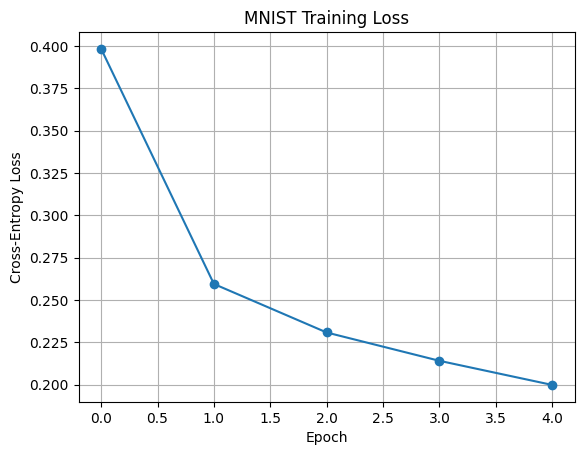

Accuracy: 94.11


In [19]:
plt.plot(losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("MNIST Training Loss")
plt.grid(True)
plt.show()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy}")
